In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/dsizzle67/Project3-DS4002/main/DATA/MetObjects_FINAL.csv'

data = pd.read_csv(url)

data.head()


,Object Number,Title,Period,Classification,Link Resource
0,12.37.135,NaN,Qing dynasty (1644–1911),Paintings,http://www.metmuseum.org/art/collection/search...
1,13.100.22,明 丁雲鵬 潯陽送客圖 軸|Song of the Lute,late Ming dynasty (1368–1644),Paintings,http://www.metmuseum.org/art/collection/search...
2,13.100.25,清 佚名 倣王翬 倣李成山水圖 軸|Landscape after Li C...,Qing dynasty (1644–1911),Paintings,http://www.metmuseum.org/art/collection/search...
3,13.100.40,清 佚名 倣王翬 倣仇實父採菱圖 扇|Gathering Water Che...,Qing dynasty (1644–1911),Paintings,http://www.metmuseum.org/art/collection/search...
4,13.100.42,清 佚名 倣王鑑 倣惠崇山水圖 扇|Landscape in the Sty...,Qing dynasty (1644–1911),Paintings,http://www.metmuseum.org/art/collection/search...


In [3]:
# 1. Tabular Data Cleaning & Filtering

# Filter by Classification: Ensure your dataset only includes paintings. (If Classification == 'Paintings' isn't already applied to the 
# whole dataset, apply it).

# Handle Missing Values: Drop any rows where Period or Link Resource is NaN.

In [4]:
df_paintings = data[data['Classification'] == 'Paintings'].copy()
df_paintings.dropna(subset=['Period', 'Link Resource'], inplace=True)

print(f"Data size after cleaning: {df_paintings.shape[0]} paintings remain.")



Data size after cleaning: 2731 paintings remain.


In [5]:
# Target Variable ('Period') Distribution & Grouping

# Frequency Analysis: Run data['Period'].value_counts() to see the distribution of time periods.

# String Cleaning & Grouping: Looking at your screenshot, you have entries like "late Ming dynasty" and "Qing dynasty". 
# You will need to clean these strings (e.g., removing "late", "early", or exact years) to consolidate them into broader parent classes.

# Class Selection: Identify your top 3 consolidated periods. Group the remaining periods into your "Other" class. Plot this final 
# distribution with a bar chart to visualize your class balance.

Top 3 Categories: ['Edo Period', 'Qing Dynasty', 'Ming Dynasty']


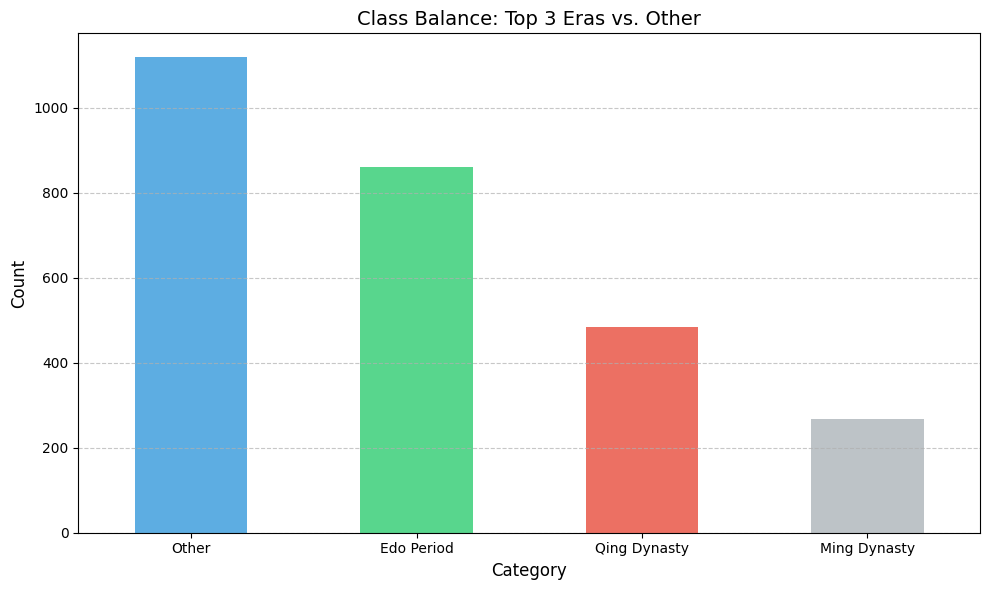

In [6]:
import re
import matplotlib.pyplot as plt

def clean_period_advanced(text):
    # Convert to string and lowercase for uniform matching
    text = str(text).lower()
    
    # 1. Remove dates, parentheses, brackets, and question marks
    # This cleans "(1368-1644)", "(?)", and "[...]"
    text = re.sub(r'\(.*?\)', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = text.replace('?', '').strip()

    # 2. Identify "Multiple Eras" 
    # If the row contains "or", ";", "and", or a hyphen between words, 
    # we treat it as a multi-period group.
    multi_indicators = [' or ', ';', ' - ', '–', ' and ']
    if any(sep in text for sep in multi_indicators):
        return "Multiple Eras"

    # 3. Keyword mapping for consolidated groups
    # This ensures "Late Ming" and "Ming Dynasty" both become "Ming Dynasty"
    mapping = {
        'ming': 'Ming Dynasty',
        'qing': 'Qing Dynasty',
        'yuan': 'Yuan Dynasty',
        'song': 'Song Dynasty',
        'edo': 'Edo Period',
        'goryeo': 'Goryeo Dynasty',
        'heian': 'Heian Period',
        'muromachi': 'Muromachi Period',
        'momoyama': 'Momoyama Period',
        'nara': 'Nara Period'
    }

    for key, official_name in mapping.items():
        if key in text:
            return official_name

    # 4. Standardize any remaining single eras (Removing modifiers)
    text = re.sub(r'\b(late|early|mid|first|second half)\b', '', text).strip()
    
    return text.title() if text != "" else "Unknown"

# --- Apply Logic ---

# 1. Create the cleaned column
df_paintings['Clean_Period'] = df_paintings['Period'].apply(clean_period_advanced)

# 2. Identify the Top 3 most frequent categories
top_3_periods = df_paintings['Clean_Period'].value_counts().nlargest(3).index.tolist()
print(f"Top 3 Categories: {top_3_periods}")

# 3. Create the Final Class: Top 3 vs. Other
df_paintings['Final_Class'] = df_paintings['Clean_Period'].apply(
    lambda x: x if x in top_3_periods else 'Other'
)

# 4. Visualize the distribution
class_counts = df_paintings['Final_Class'].value_counts()

plt.figure(figsize=(10, 6))
colors = ['#5dade2', '#58d68d', '#ec7063', '#bdc3c7'] # Professional palette
class_counts.plot(kind='bar', color=colors[:len(class_counts)])

plt.title('Class Balance: Top 3 Eras vs. Other', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0) # Keeps labels horizontal for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
import requests
from PIL import Image
from io import BytesIO
import time

# 1. Extract the Object ID from the end of the Link Resource URL
df_paintings['Object_ID'] = df_paintings['Link Resource'].str.split('/').str[-1]

# 2. Take a pilot sample of 50 images
pilot_df = df_paintings.head(50).copy()
image_stats = []

print("Fetching images from the MET API (this will take a few seconds)...")

for index, row in pilot_df.iterrows():
    obj_id = row['Object_ID']
    # The Met's public API endpoint for getting object data
    api_url = f"https://collectionapi.metmuseum.org/public/collection/v1/objects/{obj_id}"
    
    try:
        # Call API to get the JSON data for this specific painting
        response = requests.get(api_url).json()
        
        # Look for the primary image URL
        img_url = response.get('primaryImageSmall') or response.get('primaryImage')
        
        if img_url:
            # Download the actual .jpg
            img_response = requests.get(img_url)
            img = Image.open(BytesIO(img_response.content))
            
            # Profile the image dimensions and color mode
            width, height = img.size
            channels = len(img.getbands()) # 3 = RGB, 1 = Grayscale
            
            image_stats.append({
                'Object_ID': obj_id,
                'Width': width,
                'Height': height,
                'Aspect_Ratio': round(width / height, 2),
                'Mode': img.mode,       # E.g., 'RGB', 'L' (Grayscale)
                'Channels': channels
            })
            
        # Pause briefly to avoid overloading the MET's servers
        time.sleep(0.1) 
        
    except Exception as e:
        print(f"Failed to fetch image for Object ID {obj_id}")

# 3. Review the Pilot Results
stats_df = pd.DataFrame(image_stats)

print("\n--- Summary Statistics for Image Sizes ---")
print(stats_df[['Width', 'Height', 'Aspect_Ratio']].describe())

print("\n--- Color Channel Check ---")
print(stats_df['Mode'].value_counts())
print("\n*Note: Any image with Mode 'L' or Channels < 3 will need to be converted to RGB later for your CNN!*")

Fetching images from the MET API (this will take a few seconds)...

--- Summary Statistics for Image Sizes ---
           Width      Height  Aspect_Ratio
count   50.00000   50.000000     50.000000
mean   502.62000  459.140000      1.348000
std    149.10028  161.651301      0.752739
min    145.00000  216.000000      0.230000
25%    420.00000  285.250000      0.670000
50%    599.00000  503.500000      1.190000
75%    599.00000  624.000000      2.100000
max    600.00000  625.000000      2.780000

--- Color Channel Check ---
Mode
RGB    47
L       3
Name: count, dtype: int64

*Note: Any image with Mode 'L' or Channels < 3 will need to be converted to RGB later for your CNN!*


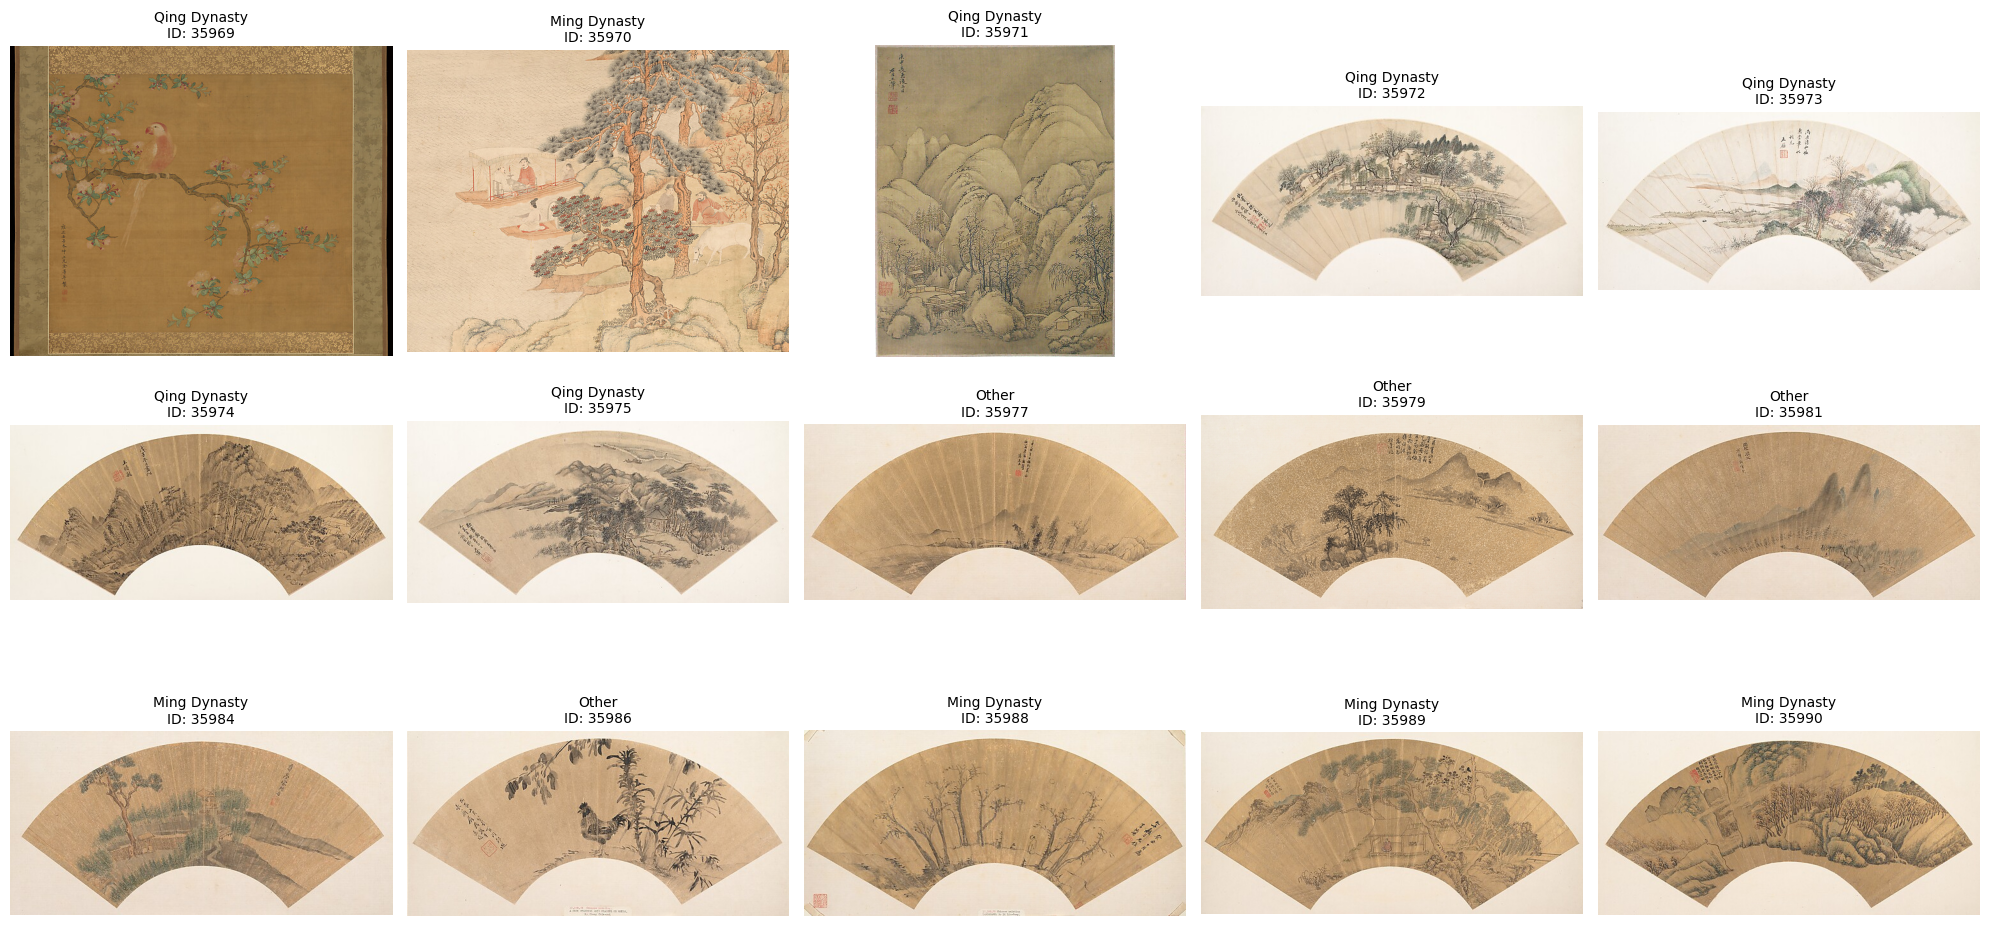

In [8]:
import matplotlib.pyplot as plt

# We'll show the images we successfully downloaded in Step 3
# Let's show up to 15 images in a 3x5 grid to keep it readable
plt.figure(figsize=(20, 10))

for i, row in pilot_df.head(15).iterrows():
    # Reuse the logic from Step 3 to get the image (or use a list of images if you saved them)
    obj_id = row['Object_ID']
    api_url = f"https://collectionapi.metmuseum.org/public/collection/v1/objects/{obj_id}"
    
    try:
        response = requests.get(api_url).json()
        img_url = response.get('primaryImageSmall') or response.get('primaryImage')
        
        if img_url:
            img_response = requests.get(img_url)
            img = Image.open(BytesIO(img_response.content))
            
            # Create a subplot
            plt.subplot(3, 5, i + 1)
            plt.imshow(img)
            plt.title(f"{row['Final_Class']}\nID: {obj_id}", fontsize=10)
            plt.axis('off')
    except:
        continue

plt.tight_layout()
plt.show()